In [ ]:
from pathlib import Path
import sys


SCENARIO_DIR = Path.cwd()
REPO_ROOT = SCENARIO_DIR.parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from modules.security.models import SecurityModelType
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline


SERIES_COLORS = {
    SecurityModelType.HOP_BY_HOP: "#0f4c5c",
    SecurityModelType.END_TO_END: "#e36414",
    SecurityModelType.EDGE_BY_EDGE: "#6a994e",
    SecurityModelType.EDGE_TO_EDGE: "#8d0801",
}

max_routes = 3
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes),
)

## Maximizar rutas sujeto a presupuesto de llaves

:::: {layout="[0.5, 0.5]"}

:::{#firstcol}
\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
B &: \text{presupuesto máximo de llaves activas} \\
\end{aligned}
:::

:::{#secondcol}
\begin{aligned}
\max \quad & \sum_{r \in R} x_r \\
\text{s.a.} \quad
& \sum_{k \in K} y_k \le B \\
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
:::


::::


In [12]:
import pandas as pd

df_m1 = pd.DataFrame()
for sec_model in SERIES_COLORS.keys():
    from models.model1_max_routes import solve_for_security_model
    
    df_m1 = pd.concat([df_m1,solve_for_security_model(result, sec_model)])

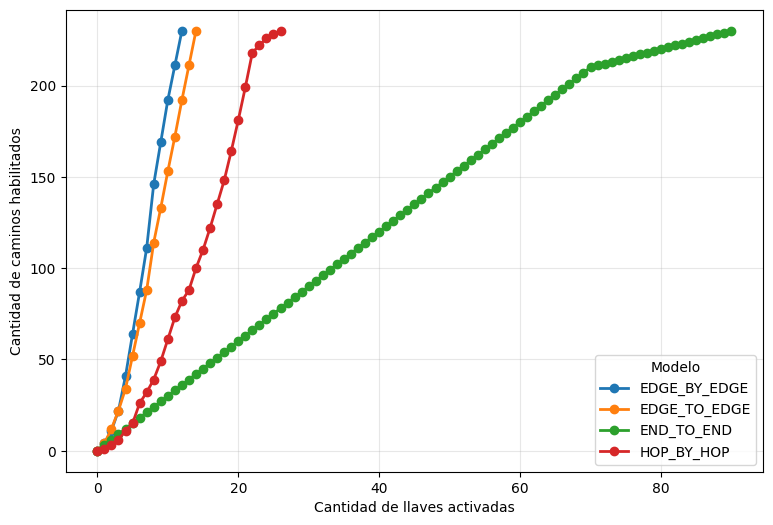

In [14]:
#| echo: false
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

for model_name, group in df_m1.groupby("model"):
    group = group.sort_values("selected_keys")
    plt.plot(
        group["selected_keys"],
        group["selected_routes"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Cantidad de llaves activadas")
plt.ylabel("Cantidad de caminos habilitados")
# plt.title("Llaves activadas vs caminos habilitados por modelo")
plt.grid(True, alpha=0.3)
plt.legend(title="Modelo")
plt.show()

## Minimizar llaves para un porcentaje de conectividad entre pares


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\alpha &: \text{fracción o porcentaje objetivo de conectividad}
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
$$
z_p =
\begin{cases}
1 & \text{si el par } p \text{ tiene al menos 1 ruta } \\
0 & \text{en otro caso}
\end{cases}
$$

:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& x_r \le z_p \qquad \forall p \in P,\ \forall r \in R_p \\
& z_p \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& \sum_{p \in P} z_p \ge \left\lceil \alpha |P| \right\rceil \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
& z_p \in \{0,1\} \qquad \forall p \in P
\end{aligned}

:::


::::


In [13]:
import pandas as pd


df_m2 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model2_min_keys import solve_for_security_model
    
    df_m2 = pd.concat([df_m2, solve_for_security_model(result,sec_model)], ignore_index=True)

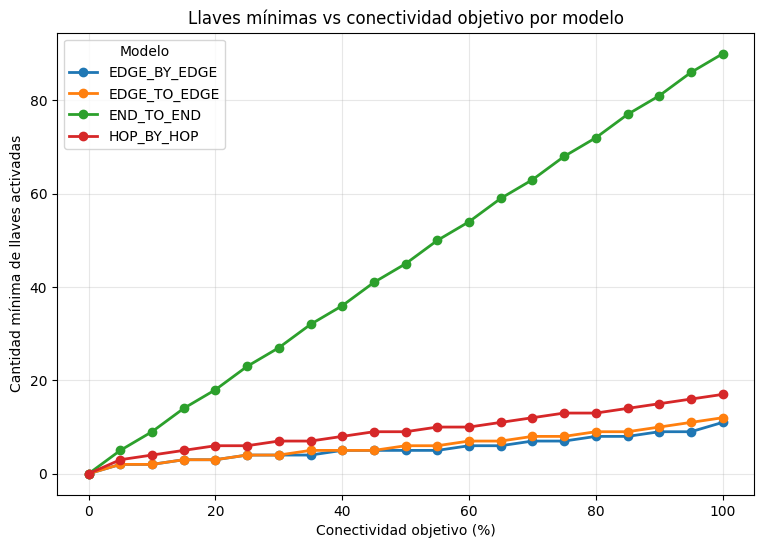

In [11]:
#| echo: false
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for model_name, group in df_m2.groupby("model"):
    group = group.sort_values("target_connectivity_pct")
    plt.plot(
        group["target_connectivity_pct"],
        group["selected_keys"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Conectividad objetivo (%)")
plt.ylabel("Cantidad mínima de llaves activadas")
plt.title("Llaves mínimas vs conectividad objetivo por modelo")
plt.grid(True, alpha=0.3)
plt.legend(title="Modelo")
plt.show()


## Minimizar llaves garantizando al menos 1 camino por par


:::: {layout="[0.5, 0.5]"}

:::{#firstcol}

\begin{aligned}
P &: \text{conjunto de pares origen-destino alcanzables de la red} \\
R_p &: \text{conjunto de rutas candidatas para el par } p \in P \\
R &= \bigcup_{p \in P} R_p \\
K &: \text{conjunto de llaves candidatas disponibles} \\
S_r &\subseteq K : \text{conjunto de llaves requeridas por la ruta } r \in R \\
\end{aligned}
$$
x_r =
\begin{cases}
1 & \text{si se selecciona la ruta } r \\
0 & \text{en otro caso}
\end{cases}
\qquad
y_k =
\begin{cases}
1 & \text{si se dispone la llave } k \\
0 & \text{en otro caso}
\end{cases}
$$
:::

:::{#secondcol}


\begin{aligned}
\min \quad & \sum_{k \in K} y_k \\
\text{s.a.} \quad
& \sum_{k \in S_r} y_k \ge |S_r|\,x_r \qquad \forall r \in R \\
& 1 \le \sum_{r \in R_p} x_r \qquad \forall p \in P \\
& x_r \in \{0,1\} \qquad \forall r \in R \\
& y_k \in \{0,1\} \qquad \forall k \in K \\
\end{aligned}

:::


::::


In [15]:
import pandas as pd


df_m3 = pd.DataFrame()

for sec_model in SERIES_COLORS.keys():
    from models.model3_min_keys_full_connectivity import solve_for_security_model
    
    df_m3 = pd.concat([df_m3, solve_for_security_model(result,sec_model)], ignore_index=True)

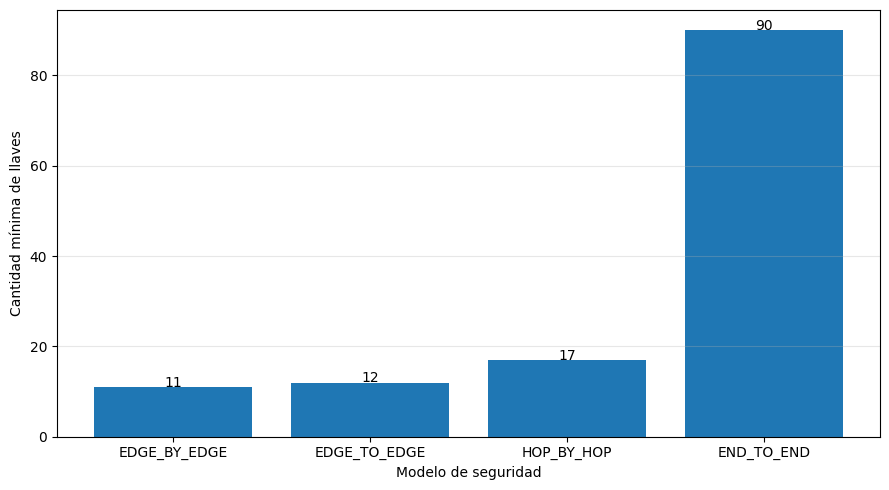

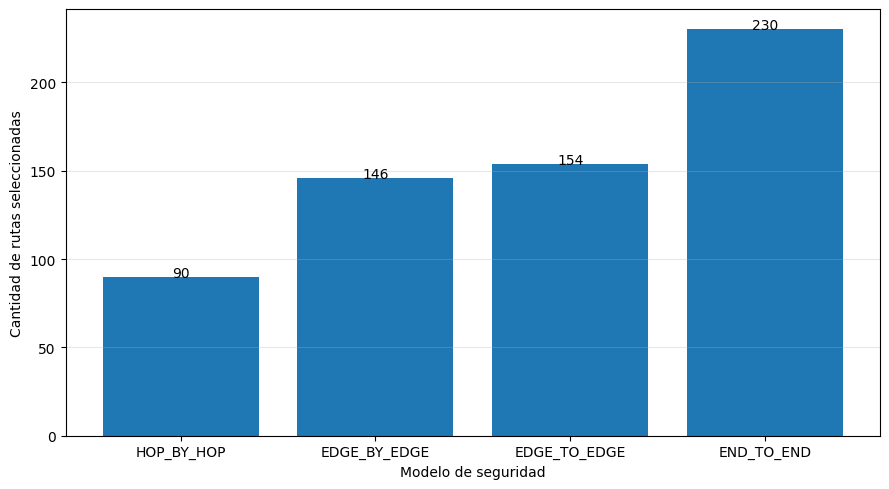

In [18]:
#| label: fig-gapminder
#| fig-cap: "Resultados de modelo 3"
#| fig-subcap:
#|   - "Llaves mínimas para garantizar al menos 1 camino por par"
#|   - "Rutas seleccionadas en la solución óptima"
#| layout-ncol: 2
#| column: page
#| echo: false
#| out-width: 100%

import matplotlib.pyplot as plt

plot_df = df_m3.sort_values("selected_keys").copy()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["selected_keys"])
plt.xlabel("Modelo de seguridad")
plt.ylabel("Cantidad mínima de llaves")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["selected_keys"]):
    plt.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()

plot_df = df_m3.sort_values("selected_routes").copy()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["selected_routes"])
plt.xlabel("Modelo de seguridad")
plt.ylabel("Cantidad de rutas seleccionadas")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(plot_df["selected_routes"]):
    plt.text(i, value + 0.05, str(value), ha="center")

plt.tight_layout()
plt.show()
